In [1]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [2]:
sentiment.info()
sentiment.isnull().sum()
sentiment.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


np.int64(0)

In [3]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
def simplify_sentiment(x):
    if 'Fear' in x:
        return 'Fear'
    elif 'Greed' in x:
        return 'Greed'
    else:
        return 'Neutral'

sentiment['sentiment_label'] = sentiment['classification'].apply(simplify_sentiment)
sentiment['sentiment_label'].value_counts()

sentiment_label
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64

In [5]:
sentiment = sentiment[['date', 'value', 'sentiment_label']]
sentiment.head()

,date,value,sentiment_label
0,2018-02-01,30,Fear
1,2018-02-02,15,Fear
2,2018-02-03,40,Fear
3,2018-02-04,24,Fear
4,2018-02-05,11,Fear


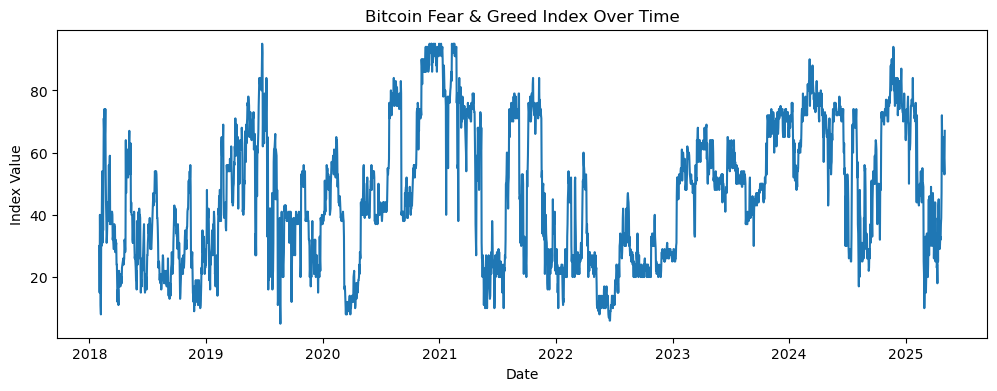

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(sentiment['date'], sentiment['value'])
plt.title("Bitcoin Fear & Greed Index Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.show()

In [7]:
sentiment['is_fear'] = (sentiment['sentiment_label'] == 'Fear').astype(int)
sentiment.head()

,date,value,sentiment_label,is_fear
0,2018-02-01,30,Fear,1
1,2018-02-02,15,Fear,1
2,2018-02-03,40,Fear,1
3,2018-02-04,24,Fear,1
4,2018-02-05,11,Fear,1


In [14]:
import pandas as pd

trades = pd.read_csv("historical_data.csv")
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [15]:
trades.shape
trades.isnull().sum()
trades.duplicated().sum()

np.int64(0)

In [16]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

In [17]:
trades['date'] = trades['Timestamp IST'].dt.date
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [18]:
trades = trades[['Account','date','Direction','Size USD','Closed PnL']]
trades.head()

,Account,date,Direction,Size USD,Closed PnL
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Buy,7872.16,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Buy,127.68,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Buy,1150.63,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Buy,1142.04,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Buy,69.75,0.0


In [19]:
trades['Direction'] = trades['Direction'].str.lower()
trades['Direction'].value_counts()

Direction
open long                    49895
close long                   48678
open short                   39741
close short                  36013
sell                         19902
buy                          16716
spot dust conversion           142
short > long                    70
long > short                    57
auto-deleveraging                8
liquidated isolated short        1
settlement                       1
Name: count, dtype: int64

In [20]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [21]:
data = trades.merge(sentiment[['date','sentiment_label']], on='date', how='left')
data.head()

,Account,date,Direction,Size USD,Closed PnL,sentiment_label
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,buy,7872.16,0.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,buy,127.68,0.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,buy,1150.63,0.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,buy,1142.04,0.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,buy,69.75,0.0,Greed


In [22]:
data['sentiment_label'].isnull().sum()

np.int64(6)

In [23]:
daily = data.groupby(['Account','date','sentiment_label']).agg(
    daily_pnl=('Closed PnL','sum'),
    num_trades=('Closed PnL','count'),
    avg_trade_size=('Size USD','mean')
).reset_index()

daily.head()

,Account,date,sentiment_label,daily_pnl,num_trades,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,0.0,177,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,0.0,68,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,0.0,40,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,-21227.0,12,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,1603.1,27,17248.148148


In [24]:
daily['win_day'] = (daily['daily_pnl'] > 0).astype(int)
daily.head()

,Account,date,sentiment_label,daily_pnl,num_trades,avg_trade_size,win_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,0.0,177,5089.718249,0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,0.0,68,7976.664412,0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,0.0,40,23734.500000,0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,-21227.0,12,28186.666667,0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,1603.1,27,17248.148148,1


In [25]:
long_ratio = data.groupby(['Account','date'])['Direction'].apply(lambda x: (x=='buy').mean()).reset_index(name='long_ratio')

daily = daily.merge(long_ratio, on=['Account','date'], how='left')
daily.head()

,Account,date,sentiment_label,daily_pnl,num_trades,avg_trade_size,win_day,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,0.0,177,5089.718249,0,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,0.0,68,7976.664412,0,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,0.0,40,23734.500000,0,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,-21227.0,12,28186.666667,0,0.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,1603.1,27,17248.148148,1,0.0


In [26]:
performance = daily.groupby('sentiment_label').agg(
    avg_pnl=('daily_pnl','mean'),
    win_rate=('win_day','mean')
).reset_index()

performance

,sentiment_label,avg_pnl,win_rate
0,Fear,5185.146443,0.603797
1,Greed,4144.208334,0.643101
2,Neutral,3438.618818,0.622340


<Figure size 640x480 with 0 Axes>

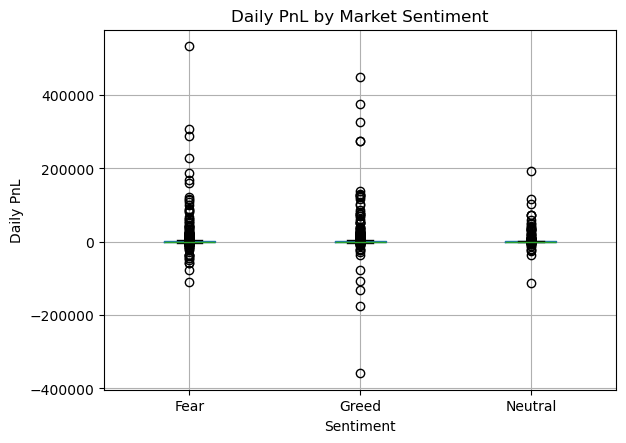

In [27]:
import matplotlib.pyplot as plt

plt.figure()
daily.boxplot(column='daily_pnl', by='sentiment_label')
plt.title('Daily PnL by Market Sentiment')
plt.suptitle('')
plt.xlabel('Sentiment')
plt.ylabel('Daily PnL')
plt.show()

In [28]:
behavior = daily.groupby('sentiment_label').agg(
    avg_trades=('num_trades','mean'),
    avg_size=('avg_trade_size','mean'),
    avg_long_ratio=('long_ratio','mean')
).reset_index()

behavior

,sentiment_label,avg_trades,avg_size,avg_long_ratio
0,Fear,105.363291,8529.859802,0.085861
1,Greed,76.912266,5954.632633,0.119155
2,Neutral,100.228723,6963.694861,0.103135


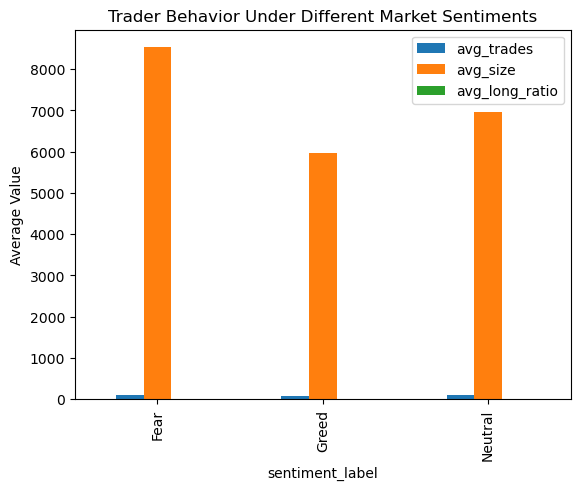

In [29]:
behavior.set_index('sentiment_label')[['avg_trades','avg_size','avg_long_ratio']].plot(kind='bar')
plt.title("Trader Behavior Under Different Market Sentiments")
plt.ylabel("Average Value")
plt.show()

In [30]:
daily['risk_group'] = pd.qcut(daily['avg_trade_size'], q=2, labels=['Low Risk','High Risk'])

daily.groupby(['risk_group','sentiment_label'])['daily_pnl'].mean().unstack()

C:\Users\AFRIYA BEGAM\AppData\Local\Temp\ipykernel_10984\250758001.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily.groupby(['risk_group','sentiment_label'])['daily_pnl'].mean().unstack()


sentiment_label,Fear,Greed,Neutral
risk_group,,,
Low Risk,970.718315,2926.039596,829.330088
High Risk,9551.641566,5285.990252,6403.719647


In [31]:
daily['activity_group'] = pd.qcut(daily['num_trades'], q=2, labels=['Low Activity','High Activity'])

daily.groupby(['activity_group','sentiment_label'])['daily_pnl'].mean().unstack()

C:\Users\AFRIYA BEGAM\AppData\Local\Temp\ipykernel_10984\3523472289.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily.groupby(['activity_group','sentiment_label'])['daily_pnl'].mean().unstack()


sentiment_label,Fear,Greed,Neutral
activity_group,,,
Low Activity,848.559834,1497.523479,1118.075454
High Activity,9391.959887,6882.632698,5759.162182


In [32]:
consistency = daily.groupby('Account')['win_day'].mean().reset_index()
consistency['consistency_group'] = pd.qcut(consistency['win_day'], q=2, labels=['Inconsistent','Consistent'])

daily = daily.merge(consistency[['Account','consistency_group']], on='Account')

daily.groupby(['consistency_group','sentiment_label'])['daily_pnl'].mean().unstack()

C:\Users\AFRIYA BEGAM\AppData\Local\Temp\ipykernel_10984\899995383.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily.groupby(['consistency_group','sentiment_label'])['daily_pnl'].mean().unstack()


sentiment_label,Fear,Greed,Neutral
consistency_group,,,
Inconsistent,2995.069342,6158.455324,3858.799041
Consistent,6526.009974,2992.824847,3208.643634


In this project I looked at how overall market mood whether the market is in Fear or Greed connects to how traders behave and perform on the Hyperliquid platform The main idea was to understand if traders change their trading style depending on market sentiment and whether that affects their profits

I started by cleaning both the sentiment data and the historical trading data then matching them by date so each trade could be linked to the market sentiment on that day From the trade data I built daily metrics for each trader such as total daily PnL number of trades average trade size win rate and the ratio of long to short trades This helped me look at both performance and trading behavior together

The analysis showed clear differences between Fear and Greed periods Traders tend to be more active and take slightly bigger positions during Greed days which suggests more confidence in the market During Fear periods results are more unstable with bigger swings in profits and losses Traders who usually take larger positions seem to be hit harder during these Fear phases

Based on this a practical takeaway is to reduce risk during Fear markets and trade more actively but carefully during Greed periods